import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




In [27]:
!pip install pandas

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/8e/59/712db1d7040520de7a4965df15b774348980e6df45c129b8c64d0dbe74ef/pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for pytz>=2020.1 from https://files.pythonhosted.org/packages/81/c4/34e93fe5f5429d7570ec1fa436f1986fb1f00c3e0f43a589fe2bbcd22c3f/pytz-2025.2-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB 1.3 MB/s eta 0:00:09
   ---------------------------------------- 0.1/11.3 MB 812.7 kB/s eta 0:00:14
   ---------------------------------------- 0.1/11.3 MB 1.0 MB/s eta 0:00:11
    --------------------------------------- 0.2/11.3 MB 1.2 MB/s eta 0:00:10
    --------------------------------------- 0.3/11.3 MB 1.2 MB/s eta 0:00:10
   - -------------------------------------- 0.3/11.3 MB 1.2 MB/s eta 0:00:10
   - -------------------------------------- 0.4/11.3 M


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: C:\Users\IMASHI PC\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [28]:
import numpy as np
import pandas as pd


In [29]:
data = pd.read_csv('artifacts/sentiment_analysis.csv')

In [30]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


# Data Preprocessing


In [31]:
data.shape

(7920, 3)

In [32]:
data.duplicated().sum()

np.int64(0)

### Text Preprocessing

In [33]:
import re
import string

In [34]:
data["tweet"].head(5)

0    #fingerprint #Pregnancy Test https://goo.gl/h1...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
Name: tweet, dtype: object

convert uppercase to lowercase

In [35]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(x.lower() for x in x.split()))

In [36]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: object

remove links

In [37]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(re.sub(r'^https?:\/\/.*[\r\n]*','',x,flags=re.MULTILINE) for x in x.split()))

In [38]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test  #android #apps #...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: object

remove punctuations

In [39]:
string.punctuation 

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [40]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

data["tweet"] = data["tweet"].apply(remove_punctuations)
    

In [41]:
data["tweet"].head(5)

0    fingerprint pregnancy test  android apps beaut...
1    finally a transparant silicon case  thanks to ...
2    we love this would you go talk makememories un...
3    im wired i know im george i was made that way ...
4    what amazing service apple wont even talk to m...
Name: tweet, dtype: object

In [42]:
data["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911    i am completely in love with the new iphone em...
7912    tune in turn on drop out  gtd in one app  mobi...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely 90 year old neighbor with he...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

remove numbers

In [43]:
data["tweet"] = data["tweet"].str.replace('\d+', '',regex=True)

In [44]:
data["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911    i am completely in love with the new iphone em...
7912    tune in turn on drop out  gtd in one app  mobi...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely  year old neighbor with her ...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

remove stopwords

In [45]:
pip install nltk

  Obtaining dependency information for nltk from https://files.pythonhosted.org/packages/60/90/81ac364ef94209c100e12579629dc92bf7a709a84af32f8c551b02c07e94/nltk-3.9.2-py3-none-any.whl.metadata
  Obtaining dependency information for click from https://files.pythonhosted.org/packages/db/d3/9dcc0f5797f070ec8edf30fbadfb200e71d9db6b84d211e3b2085a7589a0/click-8.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for regex>=2021.8.3 from https://files.pythonhosted.org/packages/9c/1a/18e9476ee1b63aaec3844d8e1cb21842dc19272c7e86d879bfc0dcc60db3/regex-2025.10.23-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.5 kB 682.7 kB/s eta 0:00:01
     -------------------------------------- 41.5/41.5 kB 504.6 kB/s eta 0:00:00
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/d0/30/dc54f88dd4a2b5dc8a0279bdd7270e735851848b762aeb1c1184ed1f6b14/tqdm-


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: C:\Users\IMASHI PC\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [46]:
import nltk

In [47]:
nltk.download('stopwords',download_dir = 'model')

[nltk_data] Downloading package stopwords to model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
with open('model/corpora/stopwords/english','r') as file:
    sw = file.read().splitlines()

In [49]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [50]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

In [51]:
data["tweet"].head

<bound method NDFrame.head of 0       fingerprint pregnancy test android apps beauti...
1       finally transparant silicon case thanks uncle ...
2       love would go talk makememories unplug relax i...
3       im wired know im george made way iphone cute d...
4       amazing service apple wont even talk question ...
                              ...                        
7915    live loud lol liveoutloud selfie smile sony mu...
7916    would like wish amazing day make every minute ...
7917    helping lovely year old neighbor ipad morning ...
7918    finally got smart pocket wifi stay connected a...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, Length: 7920, dtype: object>

stemming

In [52]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [53]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [54]:
data["tweet"].head

<bound method NDFrame.head of 0       fingerprint pregnanc test android app beauti c...
1       final transpar silicon case thank uncl yay son...
2       love would go talk makememori unplug relax iph...
3       im wire know im georg made way iphon cute dave...
4       amaz servic appl wont even talk question unles...
                              ...                        
7915    live loud lol liveoutloud selfi smile soni mus...
7916    would like wish amaz day make everi minut coun...
7917    help love year old neighbor ipad morn made rea...
7918    final got smart pocket wifi stay connect anyti...
7919    appl barcelona appl store bcn barcelona travel...
Name: tweet, Length: 7920, dtype: object>

In [55]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


## Building Vacabulary


In [56]:
import pandas as pd

In [57]:
data = pd.read_csv('artifacts/sentiment_analysis.csv')


In [58]:
from collections import Counter
vocab = Counter()

In [59]:
vocab

Counter()

In [60]:
for sentence in data['tweet']:
    vocab.update(sentence.split())

In [61]:
len(vocab)

34348

In [62]:
data.shape

(7920, 3)

In [63]:
tokens = [key for key in vocab if vocab[key] > 10]

In [64]:
len(tokens)

1401

In [65]:
def save_vocabulary(lines,filename):
    data = '\n'.join(lines)
    file = open(filename, 'w', encoding = "utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, 'model/vocabulary.txt')

## Divide Dataset

In [106]:
x = data['tweet']
y = data['tweet']

In [107]:
!pip install scikit_learn


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: C:\Users\IMASHI PC\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [108]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data['tweet'], data['label'], test_size=0.2, random_state=42)

In [109]:
x_train

4252    Cool Car wash idea #TheIsland #BankHolidayMond...
4428    Photo: 35th #Birthday to the #Sony #walkman @t...
7374    iPads are the biggest pile of fucking $&@*# on...
1410    Yearbook? Hmmmmm #instagram #instagood #togeth...
7896    So pissed! Macbook crashes, Apple Company does...
                              ...                        
5226    #Shana #tova!!! #Jewish #newyear everyone, may...
5390    I'm so sick of buying new cell phone chargers....
860     it, Want it, Have it! Download the free #iPhon...
7603    Photo: #nikosx #iphone #beach #holiday #bw #ip...
7270    Just got an iPhone 4S :) hehe #iPhone #apple #...
Name: tweet, Length: 6336, dtype: object

In [110]:
x_test

4896    Photo: cause we both dressed up today  #boyfr...
7539    @skullcandy your product is brutal, 1 headphon...
1677    Sunset Today in Zeeland ;-) Samsung Mobile S4 ...
1964    God $&@*# it playstation share feature!! Cutti...
3025    Awe he's da bestest :) #boyfriend him #iloveyo...
                              ...                        
1419    Who is 15 today? Meee #Birthday #to #me #cake ...
3939    @arualcampbell as if you you do nothing but re...
7834    using new #macbookpro for last 3 days & batter...
5137    @robertwindon I can't fix junk apple power cor...
4434    Using my zoooom.... #zoom #lens #iphone #dogwa...
Name: tweet, Length: 1584, dtype: object

In [111]:
y_train

4252    0
4428    0
7374    1
1410    0
7896    1
       ..
5226    0
5390    1
860     0
7603    0
7270    1
Name: label, Length: 6336, dtype: int64

## Vectorization

In [112]:
import numpy as np

In [113]:
def vectorizer(ds, vocabulary):
    vectorized_lst = []

    for sentence in ds:
        sentence_lst = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_lst[i] = 1

        vectorized_lst.append(sentence_lst)

    vectorized_lst_new = np.asarray(vectorized_lst, dtype = np.float32)
    return vectorized_lst_new

In [114]:
vectorized_x_train = vectorizer(x_train,tokens)

In [115]:
vectorized_x_train = vectorizer(x_test,tokens)

In [116]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1401), dtype=float32)

In [117]:
y_train

4252    0
4428    0
7374    1
1410    0
7896    1
       ..
5226    0
5390    1
860     0
7603    0
7270    1
Name: label, Length: 6336, dtype: int64

In [118]:
y_train.value_counts()

label
0    4742
1    1594
Name: count, dtype: int64

In [119]:
import matplotlib.pyplot as plt

([<matplotlib.patches.Wedge at 0x15fe5f75c90>,
 [Text(-0.7739513813435025, 0.781664416048527, 'Positive'),
  Text(0.7739512633154506, -0.7816645329119253, 'Negative')])

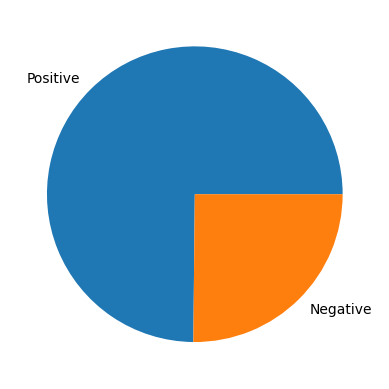

In [120]:
plt.pie(np.array([y_train.value_counts()[0],y_train.value_counts()[1]]),labels = ['Positive','Negative'])

## Handle Imbalanced Dataset

In [121]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: C:\Users\IMASHI PC\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [122]:
from sklearn.model_selection import train_test_split

X = data['tweet']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
vectorized_x_train = vectorizer.fit_transform(X_train)

In [124]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train,y_train)
print(vectorized_x_train_smote.shape,y_train_smote.shape)

(9484, 19704) (9484,)


In [125]:
y_train_smote.value_counts()

label
0    4742
1    4742
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x15fe5f4dc10>,
 [Text(-4.8082529002048655e-08, 1.099999999999999, 'Positive'),
  Text(1.311736850028664e-08, -1.0999999999999999, 'Negative')])

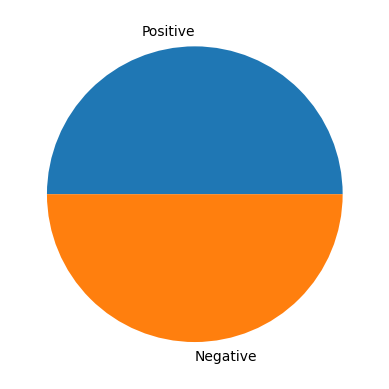

In [126]:
plt.pie(np.array([y_train_smote.value_counts()[0],y_train_smote.value_counts()[1]]),labels = ['Positive','Negative'])

In [127]:
from sklearn.model_selection import train_test_split

X = data['tweet']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
y_train

4252    0
4428    0
7374    1
1410    0
7896    1
       ..
5226    0
5390    1
860     0
7603    0
7270    1
Name: label, Length: 6336, dtype: int64

In [129]:
vectorized_x_train_smote

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 196039 stored elements and shape (9484, 19704)>

In [130]:
y_train_smote

0       0
1       0
2       1
3       0
4       1
       ..
9479    1
9480    1
9481    1
9482    1
9483    1
Name: label, Length: 9484, dtype: int64

In [131]:
y_test

4896    0
7539    1
1677    0
1964    0
3025    0
       ..
1419    0
3939    0
7834    1
5137    1
4434    0
Name: label, Length: 1584, dtype: int64

## Model Training and Evaluation

In [132]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: C:\Users\IMASHI PC\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB      
from sklearn.tree import DecisionTreeClassifier     
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [153]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred),3)
    pr = round(precision_score(y_act, y_pred),3)
    rec = round(recall_score(y_act, y_pred),3)
    f1 = round(f1_score(y_act,y_pred),3)
    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred),3)
    pr = round(precision_score(y_act, y_pred),3)
    rec = round(recall_score(y_act, y_pred),3)
    f1 = round(f1_score(y_act,y_pred),3)
    print(f'Testing Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')


### Logistic Regression

In [154]:
lr = LogisticRegression()
lr.fit(vectorized_x_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [155]:
y_train_pred = lr.predict(vectorized_x_train_smote)

In [156]:
y_train_pred

array([0, 0, 1, ..., 1, 1, 1], shape=(9484,))

In [157]:
y_train_smote

0       0
1       0
2       1
3       0
4       1
       ..
9479    1
9480    1
9481    1
9482    1
9483    1
Name: label, Length: 9484, dtype: int64

In [158]:
training_scores(y_train_smote,y_train_pred)

Testing Scores:
	Accuracy = 0.947
	Precision = 0.926
	Recall = 0.972
	F1-Score = 0.948


In [159]:
vectorizer = TfidfVectorizer()
vectorized_x_train = vectorizer.fit_transform(x_train)


vectorized_x_test = vectorizer.transform(x_test)

In [160]:
y_test_pred = lr.predict(vectorized_x_test)

In [161]:
y_test_pred

array([0, 1, 0, ..., 1, 1, 0], shape=(1584,))

In [162]:
y_test

4896    0
7539    1
1677    0
1964    0
3025    0
       ..
1419    0
3939    0
7834    1
5137    1
4434    0
Name: label, Length: 1584, dtype: int64

In [167]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def validation_scores(actual, predicted):
    acc = accuracy_score(actual, predicted)
    prec = precision_score(actual, predicted, average='weighted', zero_division=0) # 'average' parameter එක අවශ්‍ය විය හැක
    rec = recall_score(actual, predicted, average='weighted', zero_division=0)
    f1 = f1_score(actual, predicted, average='weighted', zero_division=0)
    
    print("Testing Scores:")
    print(f"Accuracy = {round(acc, 3)}") # <-- මෙලෙස වට කරන්න
    print(f"Precision = {round(prec, 3)}")
    print(f"Recall = {round(rec, 3)}")
    print(f"F1-Score = {round(f1, 3)}")

In [168]:
validation_scores(y_test, y_test_pred)

Testing Scores:
Accuracy = 0.888
Precision = 0.901
Recall = 0.888
F1-Score = 0.891


### Naive Bayes

In [170]:
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = mnb.predict(vectorized_x_train_smote)

y_test_pred = mnb.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Testing Scores:
	Accuracy = 0.93
	Precision = 0.882
	Recall = 0.992
	F1-Score = 0.934
Testing Scores:
Accuracy = 0.875
Precision = 0.904
Recall = 0.875
F1-Score = 0.88


### Decision Tree

In [172]:
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = dt.predict(vectorized_x_train_smote)

y_test_pred = dt.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Testing Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
Accuracy = 0.843
Precision = 0.847
Recall = 0.843
F1-Score = 0.845


### Random Firest

In [173]:
rf = RandomForestClassifier()
rf.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = rf.predict(vectorized_x_train_smote)

y_test_pred = rf.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Testing Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
Accuracy = 0.883
Precision = 0.891
Recall = 0.883
F1-Score = 0.885


### Support Vector Machine

In [174]:
svm = SVC()
svm.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = svm.predict(vectorized_x_train_smote)

y_test_pred = svm.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Testing Scores:
	Accuracy = 0.994
	Precision = 0.989
	Recall = 0.999
	F1-Score = 0.994
Testing Scores:
Accuracy = 0.886
Precision = 0.888
Recall = 0.886
F1-Score = 0.887


In [177]:
import pickle
with open('model.pickle','wb') as file:
    pickle.dump(lr,file)